In [3]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from tensorflow.keras import models,layers,utils
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2

In [4]:
model_cnn = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Rescaling(1/255.0),
    layers.Conv2D(kernel_size=(3,3), filters=16, padding="same", activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(kernel_size=(3,3), filters=32, padding="same", activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(kernel_size=(3,3), filters=64, padding="same", activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(units=64, activation="relu"),
    layers.Dense(units=32, activation="relu"),
    layers.Dense(units=8, activation="relu"),
    layers.Dense(units=2, activation="softmax")
])

In [5]:
model_cnn.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [6]:
data_train = utils.image_dataset_from_directory("dataset", image_size=(128,128), validation_split=0.2, subset="training", seed=40, batch_size=32)
data_test = utils.image_dataset_from_directory("dataset", image_size=(128,128), validation_split=0.2, subset="validation", seed=40, batch_size=32)

Found 3017 files belonging to 2 classes.
Using 2414 files for training.
Found 3017 files belonging to 2 classes.
Using 603 files for validation.


In [7]:
history = model_cnn.fit(
    x=data_train,
    validation_data=data_test,
    epochs=100
)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.5116 - loss: 0.6925 - val_accuracy: 0.5390 - val_loss: 0.6906
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 303ms/step - accuracy: 0.5017 - loss: 0.6922 - val_accuracy: 0.5390 - val_loss: 0.6880
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5398 - loss: 0.6907 - val_accuracy: 0.4677 - val_loss: 0.6951
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.5655 - loss: 0.6848 - val_accuracy: 0.5920 - val_loss: 0.6679
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.5837 - loss: 0.6721 - val_accuracy: 0.5970 - val_loss: 0.6580
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.6094 - loss: 0.6550 - val_accuracy: 0.6086 - val_loss: 0.6434
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6031 - loss: 0.6574 - val_accuracy: 0.5920 - val_loss: 0.6450
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.6143 - loss: 0.6454 - val_accuracy

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data_test = utils.image_dataset_from_directory(
    "dataset",
    image_size=(128,128),
    validation_split=0.2,
    subset="validation",
    seed=40,
    batch_size=32,
    shuffle=False
)

predic = np.argmax(model_cnn.predict(data_test), axis=1)

y_true_list = []

for images, labels in data_test:
    y_true_list.append(labels.numpy())

true_data = np.concatenate(y_true_list)

print("Accuracy:", accuracy_score(true_data, predic))
print("Precision:", precision_score(true_data, predic, average="weighted"))
print("Recall:", recall_score(true_data, predic, average="weighted"))
print("F1-score:", f1_score(true_data, predic, average="weighted"))
print(classification_report(true_data, predic, target_names=["cat", "dog"]))


Found 3017 files belonging to 2 classes.
Using 603 files for validation.
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Accuracy: 0.8938640132669984
Precision: 1.0
Recall: 0.8938640132669984
F1-score: 0.9439579684763573
              precision    recall  f1-score   support

         cat       0.00      0.00      0.00         0
         dog       1.00      0.89      0.94       603

    accuracy                           0.89       603
   macro avg       0.50      0.45      0.47       603
weighted avg       1.00      0.89      0.94       603



c:\Users\RSKALA\Desktop\Python Files\ByteCore\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RSKALA\Desktop\Python Files\ByteCore\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RSKALA\Desktop\Python Files\ByteCore\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

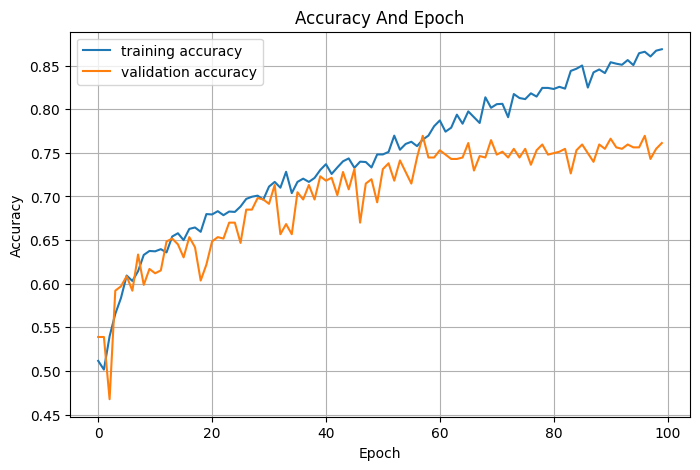

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy And Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
print("Best validation accuracy:", max(history.history["val_accuracy"]))
print("Best epoch:", np.argmax(history.history["val_accuracy"]) + 1)

Best validation accuracy: 0.7694858908653259
Best epoch: 58
